# 03. Evasion Analysis

This notebook demonstrates the **robustness and evasion phase** of the project.

The main question is no longer "what circuit exists?" but:
- what happens to that circuit under conservative, runnable obfuscation?

In mechanistic terms:
- Does obfuscation remove the validated route?
- Or does the model still represent the malicious evidence internally, while changing how it uses that evidence downstream?

In plain language:
- Is the model actually fooled because it stops seeing the danger?
- Or does it still "notice" the danger, but fail to rely on it by the end?

In [ ]:
from pathlib import Path
import math
import sys
import textwrap

import circuitsvis as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display

plt.style.use("ggplot")
sns.set_context("talk")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)


def find_project_root() -> Path:
    candidates = [Path.cwd()] + list(Path.cwd().parents)
    for candidate in candidates:
        if (candidate / "artifacts").exists() and (candidate / "scaled_validation.py").exists():
            return candidate
        if (candidate / "mech-interp-circuit" / "artifacts").exists():
            return candidate / "mech-interp-circuit"
    raise FileNotFoundError("Could not find mech-interp-circuit project root from the current working directory.")


PROJECT_ROOT = find_project_root()
ARTIFACTS = PROJECT_ROOT / "artifacts"
print("Project root:", PROJECT_ROOT)
print("Artifacts dir:", ARTIFACTS)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scaled_validation import (
    DEFAULT_MODEL_NAME,
    build_hooked_transformer,
    load_hf_model_and_tokenizer,
    make_prompt,
)


NOTEBOOK_MODEL_NAME = DEFAULT_MODEL_NAME
NOTEBOOK_TEMPLATE_NAME = "meta-llama/Llama-3.1-8B-Instruct"
NOTEBOOK_DEVICE = "cpu"
NOTEBOOK_TORCH_DTYPE = "float32"
_MODEL_BUNDLE = None


def read_csv(name: str) -> pd.DataFrame:
    path = ARTIFACTS / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def show_barh(df, label_col, value_col, *, title, xlabel, color="#2B6CB0", sort=True):
    plot_df = df.copy()
    if sort:
        plot_df = plot_df.sort_values(value_col, ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(plot_df))))
    ax.barh(plot_df[label_col], plot_df[value_col], color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    return fig, ax


def get_notebook_model():
    global _MODEL_BUNDLE
    if _MODEL_BUNDLE is None:
        hf_model, tokenizer, device = load_hf_model_and_tokenizer(
            NOTEBOOK_MODEL_NAME,
            device=NOTEBOOK_DEVICE,
            torch_dtype=NOTEBOOK_TORCH_DTYPE,
        )
        model = build_hooked_transformer(
            hf_model,
            tokenizer,
            device=device,
            torch_dtype=NOTEBOOK_TORCH_DTYPE,
            template_name=NOTEBOOK_TEMPLATE_NAME,
            use_attn_result=False,
        )
        model.eval()
        _MODEL_BUNDLE = (model, tokenizer, device)
    return _MODEL_BUNDLE


def get_pair_rows(manifest: pd.DataFrame, pair_idx: int):
    group = manifest[manifest["pair_idx"] == pair_idx].copy()
    if group.empty:
        raise KeyError(f"pair_idx={pair_idx} was not found in the manifest")
    benign_row = group[group["pair_role"] == "benign"].iloc[0]
    malicious_row = group[group["pair_role"] == "malicious"].iloc[0]
    return benign_row, malicious_row


def run_prompt_with_cache(script_text: str):
    model, tokenizer, device = get_notebook_model()
    prompt = make_prompt(str(script_text))
    toks = model.to_tokens(prompt)
    logits, cache = model.run_with_cache(toks, return_type="logits")
    return model, tokenizer, toks, logits, cache


def toks_to_str_tokens_strict(model, toks):
    """
    toks: [1, seq] or [seq] int64 token IDs
    returns list[str] length == seq
    """
    toks_1d = toks[0] if toks.ndim == 2 else toks
    ids = [int(x) for x in toks_1d.detach().cpu().tolist()]

    tok = getattr(model, "tokenizer", None)
    if tok is None:
        raise ValueError("model.tokenizer is None; can't convert ids->tokens reliably.")

    return tok.convert_ids_to_tokens(ids)


def print_key_tokens_for_head(cache, model, toks, layer, head, query_pos=-1, topk=25):
    patt = cache[f"blocks.{layer}.attn.hook_pattern"][0]
    seq_len = patt.shape[-1]

    str_toks = toks_to_str_tokens_strict(model, toks)
    assert len(str_toks) == seq_len, (len(str_toks), seq_len)

    attn = patt[head, query_pos, :]
    vals, idx = torch.topk(attn, k=min(topk, seq_len))

    print(f"Top key positions for layer={layer}, head={head}, query_pos={query_pos}:")
    for i, v in zip(idx.detach().cpu().tolist(), vals.detach().cpu().tolist()):
        print(f"  k={i:3d}  attn={float(v):0.6f}  tok={repr(str_toks[i])}")


def most_attended_key_columns(cache, model, toks, layer, head, topk_per_query=5, max_out=30):
    patt = cache[f"blocks.{layer}.attn.hook_pattern"][0]
    seq_len = patt.shape[-1]
    str_toks = toks_to_str_tokens_strict(model, toks)
    assert len(str_toks) == seq_len, (len(str_toks), seq_len)

    hits = np.zeros(seq_len, dtype=np.int64)
    for q in range(seq_len):
        attn_q = patt[head, q, :]
        _, idx = torch.topk(attn_q, k=min(topk_per_query, seq_len))
        for i in idx.detach().cpu().tolist():
            hits[i] += 1

    top_idx = np.argsort(-hits)[:max_out]
    print(f"Most frequently attended key columns (vertical stripes proxy) for layer={layer}, head={head}:")
    for i in top_idx:
        print(f"  k={i:3d}  hits={int(hits[i]):3d}  tok={repr(str_toks[i])}")


def render_single_head_pattern(cache, model, toks, layer, head):
    str_toks = toks_to_str_tokens_strict(model, toks)
    head_pattern = cache[f"blocks.{layer}.attn.hook_pattern"][0, head : head + 1].detach().cpu().numpy()
    return cv.attention.attention_patterns(
        attention=head_pattern,
        tokens=str_toks,
        attention_head_names=[f"L{layer}H{head}"],
    )


## Step 1: Load the evasion benchmark artifacts

We use:
- the expanded technique-level benchmark summary
- late-carrier patching on the strongest evasion slice
- slice-specific residual and tracing summaries for the final downstream analysis


In [ ]:
benchmark = read_csv("evasion_candidate_benchmark_summary_v2.csv")
patch_variant = read_csv("evasion_path_patching_late_invoke_webrequest_variant_v2_h100_summary.csv")
trace_seed = read_csv("evasion_trace_resid_pre13_mean_delta_l12_invoke_webrequest_seed_v2_h100_summary.csv")
trace_variant = read_csv("evasion_trace_resid_pre13_mean_delta_l12_invoke_webrequest_variant_v2_h100_summary.csv")
resid_pre31_variant = read_csv("evasion_resid_pre31_mean_delta_ablate_l12_top4_invoke_webrequest_variant_v2_h100_summary.csv")
seed_pair_manifest = read_csv("evasion_pair_manifest_invoke_webrequest_seed_v2.csv")
variant_pair_manifest = read_csv("evasion_pair_manifest_invoke_webrequest_variant_v2.csv")

benchmark


## Step 2: Which evasion techniques actually work?

A useful evasion benchmark should not treat every string rewrite as equally meaningful.
Here, the important outcome is whether a conservative, syntax-preserving transform actually flips the model from `BLOCK` to `ALLOW`.


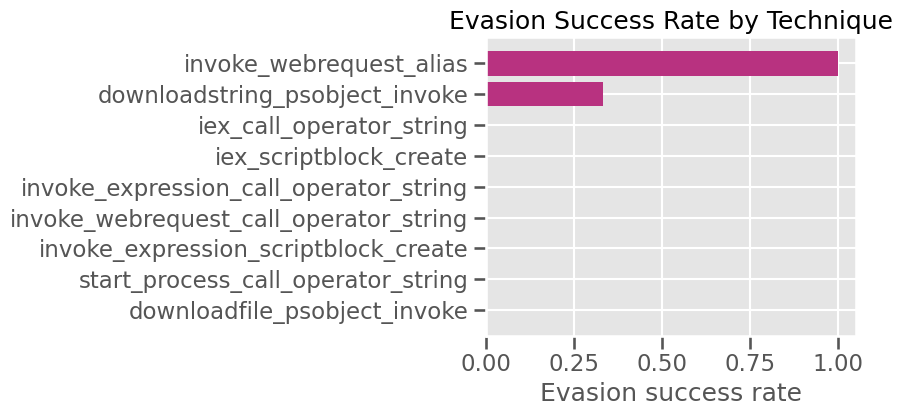

,technique_id,variant_count,evasion_success_rate,classification_change_rate,mean_variant_logit_diff,mean_logit_delta_vs_seed
0,invoke_webrequest_alias,4,1.000000,1.000000,-0.296875,-0.453125
1,downloadstring_psobject_invoke,6,0.333333,0.333333,0.940104,-1.135417
2,downloadfile_psobject_invoke,4,0.000000,0.000000,5.199219,-1.683594
3,start_process_call_operator_string,4,0.000000,0.000000,6.574219,-0.308594
4,invoke_expression_scriptblock_create,4,0.000000,0.000000,0.015625,-0.109375
5,invoke_webrequest_call_operator_string,4,0.000000,0.000000,0.234375,0.078125
6,invoke_expression_call_operator_string,4,0.000000,0.000000,0.375000,0.250000
7,iex_scriptblock_create,6,0.000000,0.000000,4.195312,0.791667
8,iex_call_operator_string,6,0.000000,0.000000,4.658854,1.255208


In [3]:
plot_df = benchmark.sort_values("evasion_success_rate", ascending=True)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_df["technique_id"], plot_df["evasion_success_rate"], color="#B83280")
ax.set_title("Evasion Success Rate by Technique")
ax.set_xlabel("Evasion success rate")
plt.tight_layout()
plt.show()

benchmark.sort_values("evasion_success_rate", ascending=False)


## Step 3: The first key surprise

On the strongest failure mode, `invoke_webrequest_alias`, the validated late carrier is still **sufficient**.

That means:
- if we patch the old late bundle back in, we can still push the model toward the malicious decision

In plain language:
- the model still knows how to use the old signal if we force it to
- but in the naturally evaded script, it is no longer relying on that signal in the same way


In [4]:
patch_variant

,patch_label,pair_count,mean_delta,max_delta,min_delta,flip_rate,mean_base_logit_diff
0,h12.15+h12.5+h12.4+h12.28,4,-1.117188,-0.59375,-1.59375,1.0,-0.296875


## Step 4: Trace the late writer family on the evaded variants

The next question is whether the late carrier disappeared.

To test that, we trace which `Layer 12` heads write most strongly into the slice-specific `resid_pre13` malicious-vs-benign direction for the evaded variants.


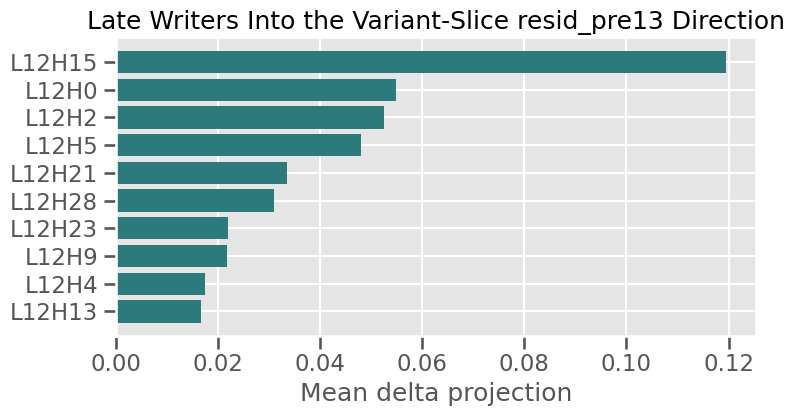

,head_label,mean_delta_projection,positive_delta_frac
0,L12H15,0.119401,1.0
1,L12H0,0.054899,1.0
2,L12H2,0.052547,1.0
3,L12H5,0.048054,1.0
4,L12H21,0.033493,1.0
5,L12H28,0.030941,1.0
6,L12H23,0.021933,1.0
7,L12H9,0.021759,1.0
8,L12H4,0.017563,1.0
9,L12H13,0.016745,1.0


In [5]:
top_trace = trace_variant.head(10).copy()
top_trace["head_label"] = top_trace.apply(lambda row: f"L{int(row['layer'])}H{int(row['head'])}", axis=1)

show_barh(
    top_trace,
    "head_label",
    "mean_delta_projection",
    title="Late Writers Into the Variant-Slice resid_pre13 Direction",
    xlabel="Mean delta projection",
    color="#2C7A7B",
    sort=True,
)
plt.show()

top_trace[["head_label", "mean_delta_projection", "positive_delta_frac"]]


## Step 4b: Visualize the top evasion-slice head directly

The tables above identify the strongest late writer on the `invoke_webrequest_alias` variants. This section loads the original malicious seed and the evaded malicious variant for one reviewed pair, then shows the same head with `circuitsvis` on both prompts.

The goal is not to prove causality from the picture alone. The goal is to make the artifact-backed claim easier to inspect by showing where that evasion-relevant head is pulling attention in token space before and after obfuscation.

In [ ]:
top_variant_head = trace_variant.sort_values(["mean_delta_projection", "positive_delta_frac"], ascending=[False, False]).iloc[0]
EVASION_LAYER = int(top_variant_head["layer"])
EVASION_HEAD = int(top_variant_head["head"])
EVASION_PAIR_IDX = int(variant_pair_manifest.loc[variant_pair_manifest["pair_role"].eq("malicious"), "pair_idx"].iloc[0])

_, seed_mal_row = get_pair_rows(seed_pair_manifest, EVASION_PAIR_IDX)
_, variant_mal_row = get_pair_rows(variant_pair_manifest, EVASION_PAIR_IDX)

model, tokenizer, seed_toks, seed_logits, seed_cache = run_prompt_with_cache(seed_mal_row["content"])
_, _, variant_toks, variant_logits, variant_cache = run_prompt_with_cache(variant_mal_row["content"])

print(f"Top variant-slice head: layer={EVASION_LAYER}, head={EVASION_HEAD}")
print(f"Reviewed evasion pair_idx={EVASION_PAIR_IDX}")
print(f"Seed file={seed_mal_row['filename']}")
print(f"Variant file={variant_mal_row['filename']}")
print("Seed malicious script:", seed_mal_row["content"])
print("Variant malicious script:", variant_mal_row["content"])

display(Markdown("### Seed prompt attention"))
display(render_single_head_pattern(seed_cache, model, seed_toks, EVASION_LAYER, EVASION_HEAD))
print_key_tokens_for_head(seed_cache, model, seed_toks, EVASION_LAYER, EVASION_HEAD, query_pos=-1, topk=20)
most_attended_key_columns(seed_cache, model, seed_toks, EVASION_LAYER, EVASION_HEAD, topk_per_query=5, max_out=20)

display(Markdown("### Evaded variant attention"))
display(render_single_head_pattern(variant_cache, model, variant_toks, EVASION_LAYER, EVASION_HEAD))
print_key_tokens_for_head(variant_cache, model, variant_toks, EVASION_LAYER, EVASION_HEAD, query_pos=-1, topk=20)
most_attended_key_columns(variant_cache, model, variant_toks, EVASION_LAYER, EVASION_HEAD, topk_per_query=5, max_out=20)


### Interpretation

The usual late writer family does **not** disappear.

The familiar heads are still there:
- `L12H15` remains dominant
- `H5`, `H2`, and `H28` remain in the main positive writer set

So the evasion is **not** well described as "the model no longer carries the malicious evidence."


## Step 5: The final downstream probe

The strongest final test asks where the sign split shows up.

Earlier in the late stage, at `resid_pre13`, the late bundle still writes the familiar malicious-evidence direction even on evaded variants.

Later, at `resid_pre31`, we test whether ablating the same late bundle still moves the late residual in the same direction.


In [6]:
resid_pre31_variant

,intervention_label,pair_count,mean_base_logit_diff,mean_intervened_logit_diff,mean_logit_delta,flip_rate,mean_base_projection,mean_intervened_projection,mean_projection_delta,positive_projection_delta_frac
0,ablate_h12.15+h12.5+h12.4+h12.28,4,-0.296875,0.046875,0.34375,0.0,11.039062,11.382812,0.34375,1.0


## Final interpretation

This is the core robustness result:

- the validated late carrier survives the evasion at `resid_pre13`
- but later blocks transform or compensate for that evidence differently
- by `resid_pre31`, the anti-causal split is already visible in the residual stream itself

In plain language:
- the model still contains the danger signal
- but later computation has changed how much the final answer depends on that signal

That is stronger and more precise than saying the circuit was simply "broken."


## Optional: Rerun notes

        These commands are GPU-friendly rather than CPU-friendly in practice, but they document the exact downstream probe used in the final writeup.


In [7]:
# Example only. Uncomment to rerun the final downstream probe.
#
# !python ../scaled_validation.py batch-residual-direction-intervention \
#     --manifest ../artifacts/evasion_pair_manifest_invoke_webrequest_variant_v2.csv \
#     --basis-path ../artifacts/evasion_invoke_webrequest_variant_v2_resid_pre31_contrastive_h100_basis.pt \
#     --basis-label mean_delta \
#     --heads 12.15,12.5,12.4,12.28 \
#     --mode ablate \
#     --device cuda \
#     --torch-dtype float16 \
#     --num-pairs 4 \
#     --allow-zero-indicator-malicious \
#     --output-prefix ../artifacts/demo_evasion_probe
